# Assignment: Neural Network on CIFAR-10 with Regularization

In this assignment, you will:
1. Build a baseline CNN for CIFAR-10 classification
2. Implement and compare regularization techniques (Dropout, BatchNorm)
3. Combine all techniques to build your best model
4. Visualize how CNNs learn (filters, feature maps, Grad-CAM)
5. Analyze and compare results

**Rules:**
- You may use PyTorch (or TensorFlow if you prefer)
- Do NOT use pretrained models
- Fill in all `# TODO` sections
- Report final test accuracy for each experiment

---

## Grading Rubric

Your grade is determined by your **Best Model** (Task 4) **final test accuracy**, evaluated in Task 6:

| Grade | Test Accuracy | Description |
|-------|--------------|-------------|
| **A+** | >= 85% | Excellent — strong architecture with well-tuned regularization |
| **A** | >= 82% | Great — good combination of techniques |
| **B+** | >= 79% | Good effort — room for optimization |
| **B** | >= 76% | Decent — used some techniques effectively |
| **C** | >= 70% | Minimal effort — near baseline performance |
| **F** | < 70% | Needs more work |

**Per-task minimum thresholds** (must pass all to receive full credit):
- Task 1 (Baseline): >= 65% — confirms a working CNN
- Task 2 (Dropout): >= 65%
- Task 3 (BatchNorm): >= 70%
- Task 4 (Best Model): >= 70%
- Task 5 (Visualization): Complete all visualizations and answer questions
- Task 6 (Analysis): Answer all questions thoughtfully

## 0. Setup

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Loading

CIFAR-10: 60,000 32x32 color images in 10 classes (50k train, 10k test).

We split the training set into **train (45k)** and **validation (5k)** so that we tune hyperparameters on the validation set and only evaluate on the test set at the very end.

In [7]:
# Basic transform (no augmentation yet)
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full training set (we will split into train + val)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)

# Split: 45k train, 5k validation
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000],
                                                  generator=torch.Generator().manual_seed(42))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:25<00:00, 6.57MB/s]


## 2. Training & Evaluation Helpers

> **Note:** Dropout and BatchNorm behave differently during training vs. evaluation. The `train()` function calls `model.train()` and `evaluate()` calls `model.eval()` — this is critical for correct results.

In [8]:
def train(model, loader, criterion, optimizer, epochs=20):
    """Train the model. Returns lists of (train_loss, train_acc) per epoch."""
    model.train()
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Epoch {epoch+1:2d}/{epochs} \u2014 Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')
    return history


def evaluate(model, loader):
    """Evaluate the model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

---
## Task 1: Baseline CNN (No Regularization)

Build a simple CNN. Suggested architecture:
- 2~3 Conv blocks (Conv2d -> ReLU -> MaxPool2d)
- 1~2 Fully connected layers
- No dropout, no batch norm, no weight decay

In [9]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Define your layers
        # Conv 블록 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # Conv 블록 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Conv 블록 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        # FC 레이어
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # TODO: Implement forward pass
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 → 8x8
        x = self.pool(self.relu(self.conv3(x)))  # 8x8 → 4x4

        x = x.view(x.size(0), -1)               # Flatten: (128*4*4,)

        x = self.relu(self.fc1(x))              # 2048 → 256
        x = self.fc2(x)                         # 256 → 10
        return x


baseline = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

hist_baseline = train(baseline, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(baseline, valloader)
print(f'\n[Baseline] Val Accuracy: {val_acc:.4f}')



Epoch  1/20 — Loss: 1.4415, Acc: 0.4792
Epoch  2/20 — Loss: 1.0181, Acc: 0.6394
Epoch  3/20 — Loss: 0.8197, Acc: 0.7116
Epoch  4/20 — Loss: 0.6863, Acc: 0.7578
Epoch  5/20 — Loss: 0.5943, Acc: 0.7920
Epoch  6/20 — Loss: 0.5026, Acc: 0.8241
Epoch  7/20 — Loss: 0.4066, Acc: 0.8557
Epoch  8/20 — Loss: 0.3289, Acc: 0.8858
Epoch  9/20 — Loss: 0.2609, Acc: 0.9091
Epoch 10/20 — Loss: 0.1973, Acc: 0.9316
Epoch 11/20 — Loss: 0.1483, Acc: 0.9473
Epoch 12/20 — Loss: 0.1310, Acc: 0.9534
Epoch 13/20 — Loss: 0.1058, Acc: 0.9625
Epoch 14/20 — Loss: 0.0785, Acc: 0.9730
Epoch 15/20 — Loss: 0.0687, Acc: 0.9753
Epoch 16/20 — Loss: 0.0837, Acc: 0.9695
Epoch 17/20 — Loss: 0.0625, Acc: 0.9787
Epoch 18/20 — Loss: 0.0649, Acc: 0.9773
Epoch 19/20 — Loss: 0.0659, Acc: 0.9773
Epoch 20/20 — Loss: 0.0625, Acc: 0.9784

[Baseline] Val Accuracy: 0.7510


---
## Task 2: Dropout Regularization

Copy your baseline and add **Dropout** layers. Experiment with dropout rates (e.g., 0.25, 0.5).

> **Tip:** Start with a lower rate like 0.25. High dropout (0.5) on small networks with few epochs can hurt training convergence — this is itself a useful observation.

In [16]:
class DropoutCNN(nn.Module):
    def __init__(self, drop_rate=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout(p=drop_rate)
        self.dropout_fc = nn.Dropout(p=min(drop_rate + 0.25, 0.5))
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.dropout_conv(self.pool(self.relu(self.conv1(x))))
        x = self.dropout_conv(self.pool(self.relu(self.conv2(x))))
        x = self.dropout_conv(self.pool(self.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


dropout_model = DropoutCNN(drop_rate=0.25).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

hist_dropout = train(dropout_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(dropout_model, valloader)
print(f'\n[Dropout] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.6281, Acc: 0.4051
Epoch  2/20 — Loss: 1.2766, Acc: 0.5409
Epoch  3/20 — Loss: 1.1232, Acc: 0.6021
Epoch  4/20 — Loss: 1.0222, Acc: 0.6382
Epoch  5/20 — Loss: 0.9441, Acc: 0.6687
Epoch  6/20 — Loss: 0.8956, Acc: 0.6871
Epoch  7/20 — Loss: 0.8561, Acc: 0.7006
Epoch  8/20 — Loss: 0.8251, Acc: 0.7115
Epoch  9/20 — Loss: 0.7899, Acc: 0.7247
Epoch 10/20 — Loss: 0.7631, Acc: 0.7315
Epoch 11/20 — Loss: 0.7387, Acc: 0.7424
Epoch 12/20 — Loss: 0.7225, Acc: 0.7454
Epoch 13/20 — Loss: 0.7065, Acc: 0.7515
Epoch 14/20 — Loss: 0.6866, Acc: 0.7571
Epoch 15/20 — Loss: 0.6729, Acc: 0.7638
Epoch 16/20 — Loss: 0.6598, Acc: 0.7672
Epoch 17/20 — Loss: 0.6497, Acc: 0.7705
Epoch 18/20 — Loss: 0.6427, Acc: 0.7728
Epoch 19/20 — Loss: 0.6265, Acc: 0.7792
Epoch 20/20 — Loss: 0.6290, Acc: 0.7797

[Dropout] Val Accuracy: 0.7874


---
## Task 3: Batch Normalization

Copy your baseline and add **BatchNorm2d** (after conv layers) and/or **BatchNorm1d** (after FC layers).

In [18]:
class BatchNormCNN(nn.Module):
    def __init__(self):
# Conv 블록 (Baseline과 동일)
        super(BatchNormCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        # TODO
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.bn_fc(self.fc1(x)))
        x = self.fc2(x)
        return x


bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')



bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.0647, Acc: 0.6212
Epoch  2/20 — Loss: 0.7224, Acc: 0.7449
Epoch  3/20 — Loss: 0.5569, Acc: 0.8068
Epoch  4/20 — Loss: 0.4327, Acc: 0.8495
Epoch  5/20 — Loss: 0.3300, Acc: 0.8874
Epoch  6/20 — Loss: 0.2443, Acc: 0.9182
Epoch  7/20 — Loss: 0.1744, Acc: 0.9436
Epoch  8/20 — Loss: 0.1231, Acc: 0.9630
Epoch  9/20 — Loss: 0.0879, Acc: 0.9742
Epoch 10/20 — Loss: 0.0725, Acc: 0.9784
Epoch 11/20 — Loss: 0.0766, Acc: 0.9753
Epoch 12/20 — Loss: 0.0573, Acc: 0.9828
Epoch 13/20 — Loss: 0.0420, Acc: 0.9881
Epoch 14/20 — Loss: 0.0578, Acc: 0.9821
Epoch 15/20 — Loss: 0.0417, Acc: 0.9877
Epoch 16/20 — Loss: 0.0489, Acc: 0.9843
Epoch 17/20 — Loss: 0.0504, Acc: 0.9833
Epoch 18/20 — Loss: 0.0408, Acc: 0.9872
Epoch 19/20 — Loss: 0.0258, Acc: 0.9927
Epoch 20/20 — Loss: 0.0196, Acc: 0.9947

[BatchNorm] Val Accuracy: 0.7606
Epoch  1/20 — Loss: 1.1078, Acc: 0.6048
Epoch  2/20 — Loss: 0.7497, Acc: 0.7377
Epoch  3/20 — Loss: 0.5819, Acc: 0.7968
Epoch  4/20 — Loss: 0.4554, Acc: 0.8438
Epoch 

---
## Task 4: Best Model — Combine Everything

Now combine the techniques that worked best. Try to **maximize validation accuracy**. (Final test accuracy is evaluated once in Task 6.)

You may use any combination of:
- BatchNorm, Dropout
- Weight decay (`weight_decay` parameter in optimizer)
- Data augmentation (e.g., `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`)
- Deeper/wider architectures
- Learning rate scheduling (`optim.lr_scheduler`)
- More epochs
- Different optimizers (SGD + momentum)

In [19]:
# (Optional) Define an augmented transform for better training
transform_aug = transforms.Compose([
    # TODO: Add augmentation transforms here (e.g., RandomHorizontalFlip, RandomCrop)
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
trainset_aug, _ = torch.utils.data.random_split(full_trainset_aug, [45000, 5000],
                                                 generator=torch.Generator().manual_seed(42))
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=128, shuffle=True, num_workers=2)


class BestCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Your best architecture with all regularization techniques combined
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout(p=0.25)
        self.dropout_fc = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # TODO
        x = self.dropout_conv(self.pool(self.relu(self.bn1(self.conv1(x)))))
        x = self.dropout_conv(self.pool(self.relu(self.bn2(self.conv2(x)))))
        x = self.dropout_conv(self.pool(self.relu(self.bn3(self.conv3(x)))))
        x = x.view(x.size(0), -1)
        x = self.dropout_fc(self.relu(self.bn_fc(self.fc1(x))))
        x = self.fc2(x)
        return x


best_model = BestCNN().to(device)
# TODO: Choose optimizer, weight decay, scheduler
optimizer = optim.Adam(best_model.parameters(), lr=1e-3)

# You may use trainloader (no augmentation) or trainloader_aug (with augmentation)
hist_best = train(best_model, trainloader_aug, criterion, optimizer, epochs=30)
val_loss, val_acc = evaluate(best_model, valloader)
print(f'\n[Best Model] Val Accuracy: {val_acc:.4f}')

Epoch  1/30 — Loss: 1.4955, Acc: 0.4558
Epoch  2/30 — Loss: 1.1706, Acc: 0.5784
Epoch  3/30 — Loss: 1.0445, Acc: 0.6292
Epoch  4/30 — Loss: 0.9628, Acc: 0.6605
Epoch  5/30 — Loss: 0.8975, Acc: 0.6818
Epoch  6/30 — Loss: 0.8664, Acc: 0.6921
Epoch  7/30 — Loss: 0.8282, Acc: 0.7101
Epoch  8/30 — Loss: 0.7987, Acc: 0.7210
Epoch  9/30 — Loss: 0.7644, Acc: 0.7311
Epoch 10/30 — Loss: 0.7398, Acc: 0.7403
Epoch 11/30 — Loss: 0.7142, Acc: 0.7491
Epoch 12/30 — Loss: 0.6960, Acc: 0.7562
Epoch 13/30 — Loss: 0.6872, Acc: 0.7606
Epoch 14/30 — Loss: 0.6615, Acc: 0.7708
Epoch 15/30 — Loss: 0.6528, Acc: 0.7720
Epoch 16/30 — Loss: 0.6385, Acc: 0.7763
Epoch 17/30 — Loss: 0.6248, Acc: 0.7820
Epoch 18/30 — Loss: 0.6118, Acc: 0.7880
Epoch 19/30 — Loss: 0.5958, Acc: 0.7913
Epoch 20/30 — Loss: 0.5935, Acc: 0.7934
Epoch 21/30 — Loss: 0.5790, Acc: 0.7973
Epoch 22/30 — Loss: 0.5737, Acc: 0.8023
Epoch 23/30 — Loss: 0.5591, Acc: 0.8056
Epoch 24/30 — Loss: 0.5573, Acc: 0.8055
Epoch 25/30 — Loss: 0.5490, Acc: 0.8088


---
## Task 5: Visualizing How CNNs Work

Understanding what happens inside a CNN is crucial for building intuition. In this section you will:

1. **Visualize first-layer convolutional filters** — what low-level patterns does the network learn?
2. **Visualize feature maps (activations)** — how does each layer transform the input image?
3. **Grad-CAM heatmaps** — where does the model "look" when making a prediction?
4. **Compare Baseline vs BatchNorm** — how does BatchNorm affect what the CNN learns?

The helper functions are provided below. Your job is to **call them on your trained models**, observe the outputs, and **answer the questions**.

In [21]:
# ===== Visualization Helpers (provided — do not modify) =====

def show_original_image(image, label=None):
    """Display a single CIFAR-10 image (un-normalized)."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image.cpu() * std + mean
    img = img.clamp(0, 1)
    plt.figure(figsize=(2, 2))
    plt.imshow(img.permute(1, 2, 0).numpy())
    if label is not None:
        plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()


def _get_conv_layers(model):
    """Return an ordered list of (name, Conv2d module) from the model."""
    convs = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            convs.append((name, module))
    return convs


def visualize_filters(model, title="First Conv Layer Filters"):
    """Visualize the filters of the first Conv2d layer."""
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return
    first_conv = conv_layers[0][1]
    filters = first_conv.weight.data.cpu().clone()
    n = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_feature_maps(model, image, title="Feature Maps"):
    """Visualize feature maps at each Conv2d layer for a single image."""
    model.eval()
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return

    # Register forward hooks on all conv layers
    activations = {}
    hooks = []
    for name, layer in conv_layers:
        def hook_fn(module, input, output, name=name):
            activations[name] = output.detach().cpu().squeeze(0)
        hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot
    for i, (name, _) in enumerate(conv_layers):
        act = activations[name]
        n_ch = min(act.shape[0], 8)
        fig, axes = plt.subplots(1, n_ch, figsize=(n_ch * 2, 2))
        if n_ch == 1:
            axes = [axes]
        for j in range(n_ch):
            axes[j].imshow(act[j], cmap='viridis')
            axes[j].axis('off')
        label = f"Conv {i+1} (ch={act.shape[0]}, {act.shape[1]}x{act.shape[2]})"
        plt.suptitle(f"{title} \u2014 {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def grad_cam(model, image, target_class=None):
    """Compute Grad-CAM heatmap for the last Conv2d layer."""
    import torch.nn.functional as F
    model.eval()

    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model.")
    last_conv = conv_layers[-1][1]

    gradients, activations_list = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations_list.append(output)

    handle_f = last_conv.register_forward_hook(forward_hook)
    handle_b = last_conv.register_full_backward_hook(backward_hook)

    input_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations_list[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.sum(weights[:, None, None] * acts, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(32, 32), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    handle_f.remove()
    handle_b.remove()
    return cam_resized, target_class


def show_grad_cam(model, image, label=None, title="Grad-CAM"):
    """Display Grad-CAM heatmap overlaid on the original image."""
    cam, pred_class = grad_cam(model, image)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')
    axes[2].imshow(img)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f"Overlay (pred: {classes[pred_class]})")
    axes[2].axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

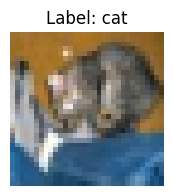

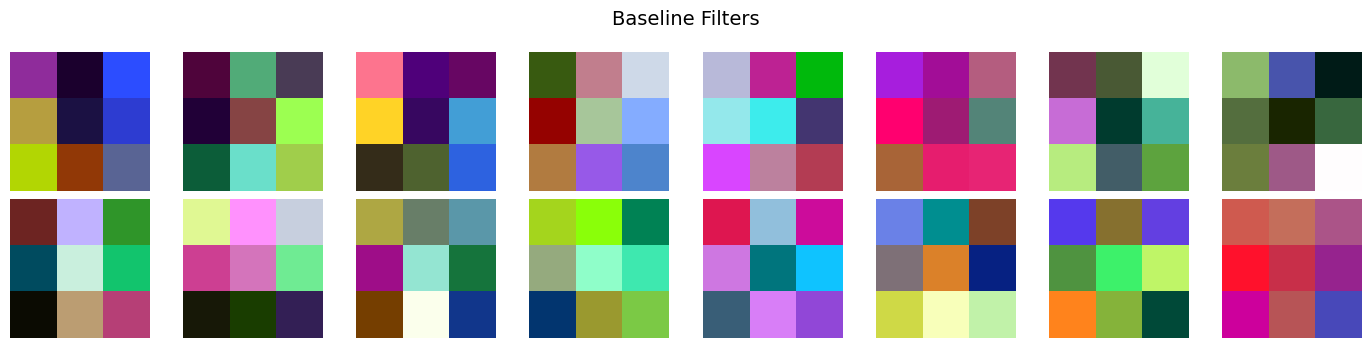

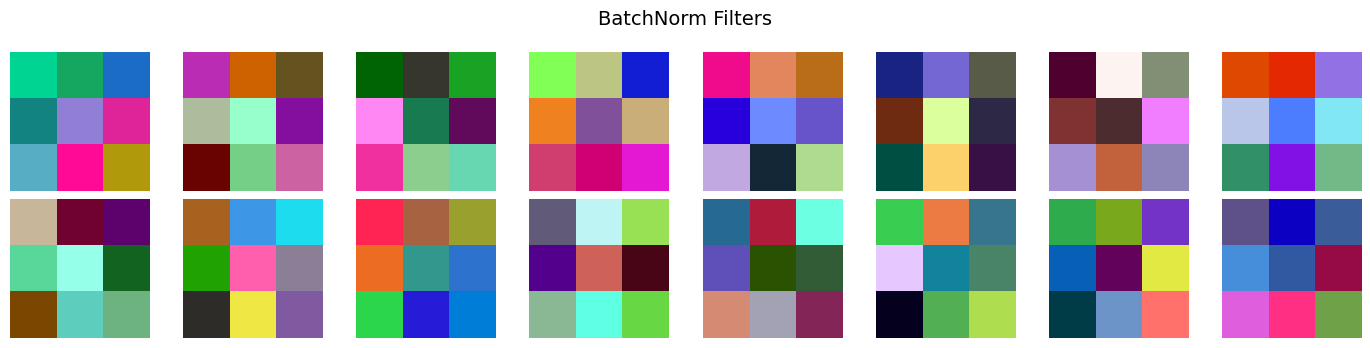

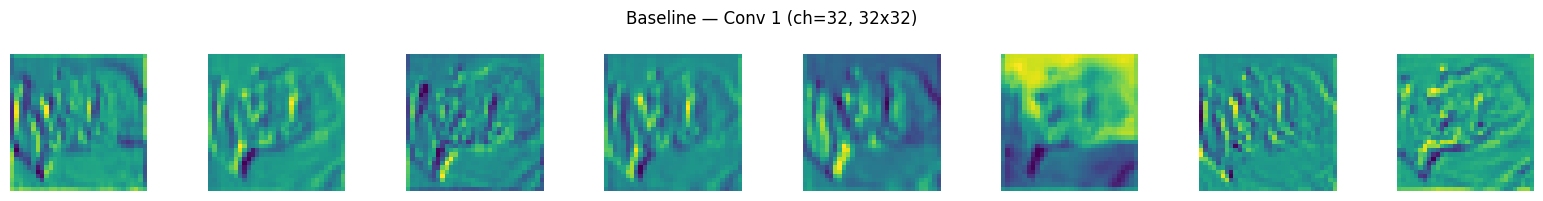

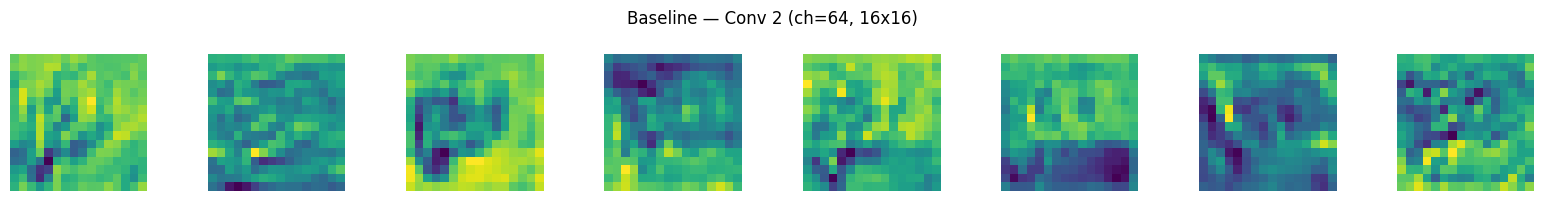

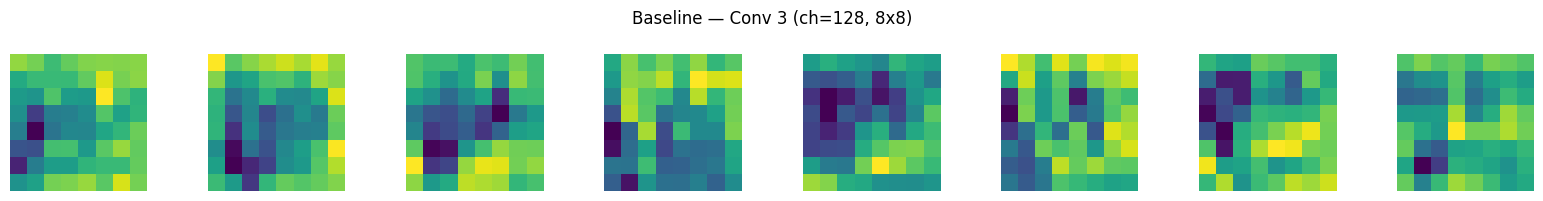

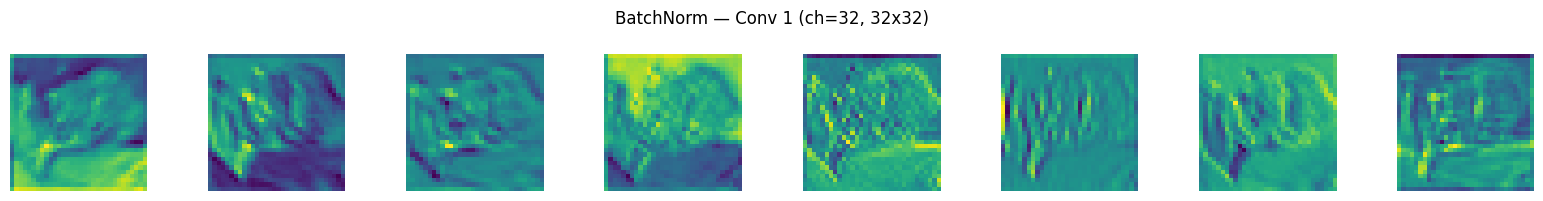

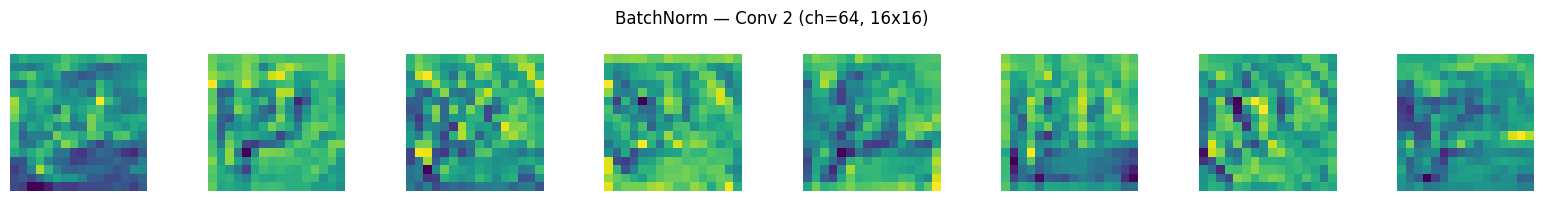

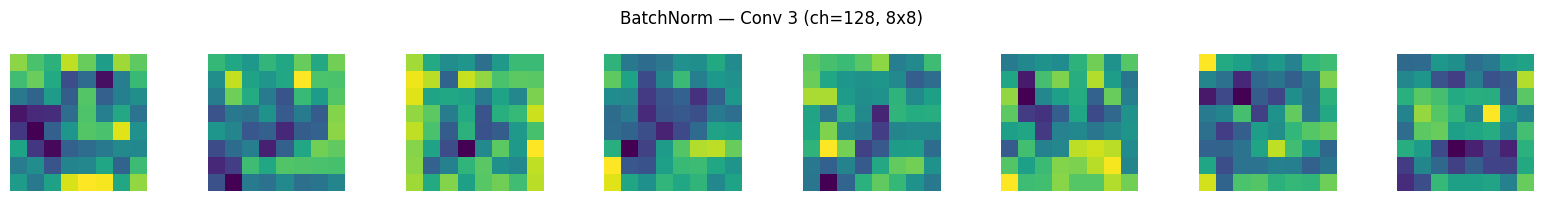

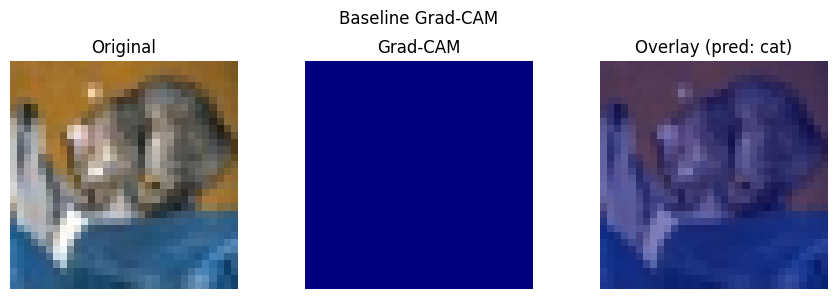

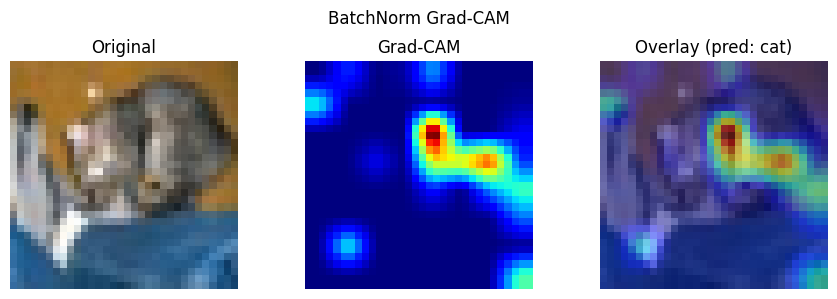

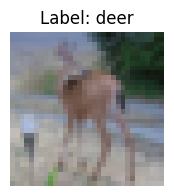

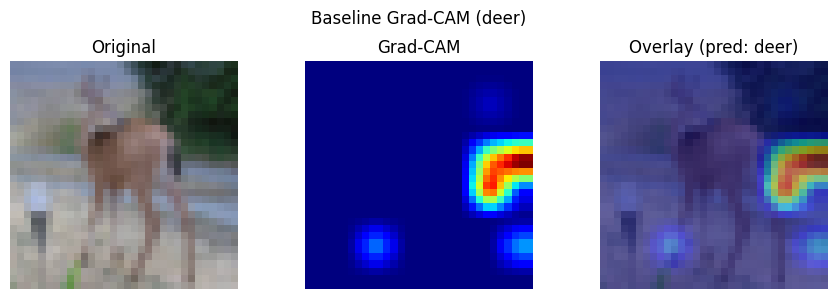

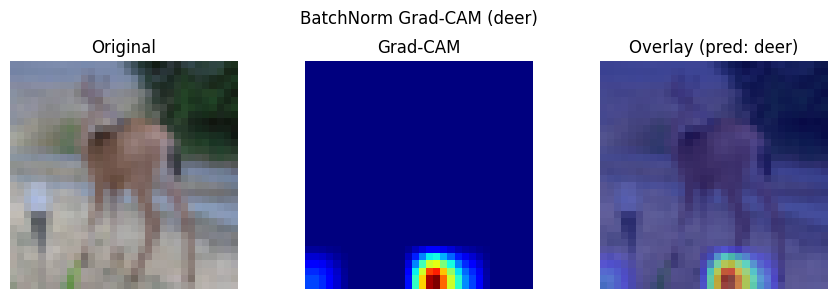

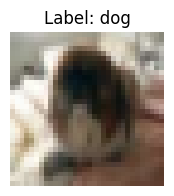

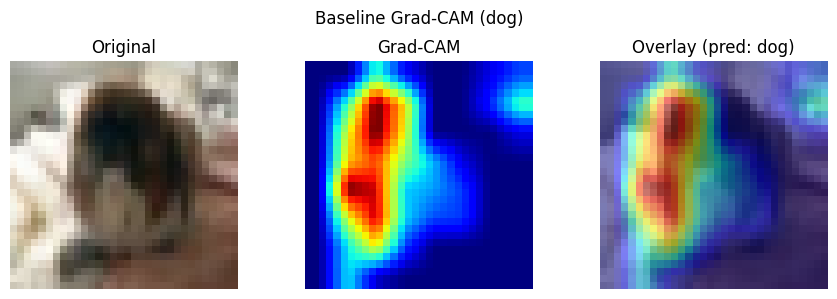

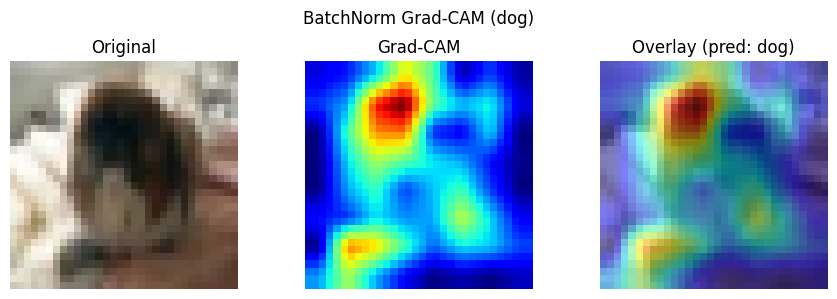

In [22]:
# --- Pick a sample image for visualization ---
sample_image, sample_label = testset[0]
show_original_image(sample_image, sample_label)

# TODO: Visualize first-layer filters for Baseline and BatchNorm models
visualize_filters(baseline, title="Baseline Filters")
visualize_filters(bn_model, title="BatchNorm Filters")


# TODO: Visualize feature maps for both models on the sample image
visualize_feature_maps(baseline, sample_image, title="Baseline")
visualize_feature_maps(bn_model, sample_image, title="BatchNorm")



# TODO: Show Grad-CAM heatmaps for both models
show_grad_cam(baseline, sample_image, title="Baseline Grad-CAM")
show_grad_cam(bn_model, sample_image, title="BatchNorm Grad-CAM")


# TODO: Try at least 3 different images from different classes and compare.
sample_image2, sample_label2 = testset[100]
show_original_image(sample_image2, sample_label2)
show_grad_cam(baseline, sample_image2, title=f"Baseline Grad-CAM ({classes[sample_label2]})")
show_grad_cam(bn_model, sample_image2, title=f"BatchNorm Grad-CAM ({classes[sample_label2]})")

sample_image3, sample_label3 = testset[200]
show_original_image(sample_image3, sample_label3)
show_grad_cam(baseline, sample_image3, title=f"Baseline Grad-CAM ({classes[sample_label3]})")
show_grad_cam(bn_model, sample_image3, title=f"BatchNorm Grad-CAM ({classes[sample_label3]})")

#       Do the models focus on different regions?

### 5-1. Observation Questions

1. Describe the patterns you see in the first-layer filters. Do they resemble edge detectors, color detectors, or something else?
2. How do feature maps change from the first conv layer to the last? What does this suggest about hierarchical feature learning?
3. Compare the Grad-CAM heatmaps of the Baseline and BatchNorm models. Does one focus on more relevant image regions?
4. Did you find any images where one model's attention (Grad-CAM) was clearly better than the other's? Describe what you found.

1. 첫 번째 레이어 필터에서 어떤 패턴이 보이는가?
Baseline과 BatchNorm 모델 모두 첫 번째 레이어 필터가 엣지(선) 탐지기보다는 색상 대비 탐지기에 가까운 형태로 학습되었습니다. 필터들이 초록-분홍, 파랑-주황, 보라-노랑 같은 보색 조합의 색상 블록 형태를 띠고 있습니다. CIFAR-10 이미지가 32×32로 매우 작기 때문에 색상 정보가 분류에 중요한 역할을 하기 때문으로 보입니다.


2. Feature Map이 첫 번째 레이어에서 마지막 레이어로 갈수록 어떻게 변하는가?
Conv1(32×32)에서는 고양이의 윤곽선과 털 결 같은 세부적인 공간 정보가 잘 보입니다. Conv2(16×16)로 갈수록 점점 추상적으로 변하고, Conv3(8×8)에서는 세부 디테일은 사라지고 고차원적인 의미 정보만 남습니다. 이는 CNN이 계층적으로 특징을 학습한다는 것을 보여줍니다. 초기 레이어는 단순한 패턴을, 깊은 레이어는 그것들을 조합한 추상적인 개념을 학습합니다..

3. Baseline과 BatchNorm의 Grad-CAM을 비교하면?
고양이 이미지에서 차이가 가장 뚜렷했습니다. Baseline 모델은 Grad-CAM이 거의 새까맣게 나와 특정 영역에 집중하지 못했지만, BatchNorm 모델은 고양이의 얼굴과 몸통 부위에 명확하게 집중(빨간색/노란색 영역)했습니다. BatchNorm이 더 의미 있는 특징을 학습하도록 도와준 결과로 보입니다.

4. 한 모델의 attention이 다른 모델보다 명확히 더 나은 이미지가 있었는가?
고양이 이미지에서 가장 큰 차이가 있었습니다. Baseline은 집중 영역이 거의 없었던 반면 BatchNorm은 고양이 머리 부분에 명확히 집중했습니다. 반면 사슴 이미지에서는 반대로 Baseline이 사슴의 등 부분에 더 잘 집중했고 BatchNorm은 거의 집중하지 못했습니다. 강아지 이미지에서는 두 모델 모두 강아지 몸통에 집중했지만 Baseline이 한 곳에 더 집중된 반면 BatchNorm은 여러 부위에 분산되었습니다. 이를 통해 BatchNorm이 평균적으로는 더 나은 attention을 보이지만 항상 그런 것은 아님을 알 수 있습니다.

---
## Task 6: Analysis

### 6-1. Compare Results

Final Test Set Evaluation:
  Baseline       : 0.7502
  Dropout        : 0.7883
  BatchNorm      : 0.7661
  Best Model     : 0.8525


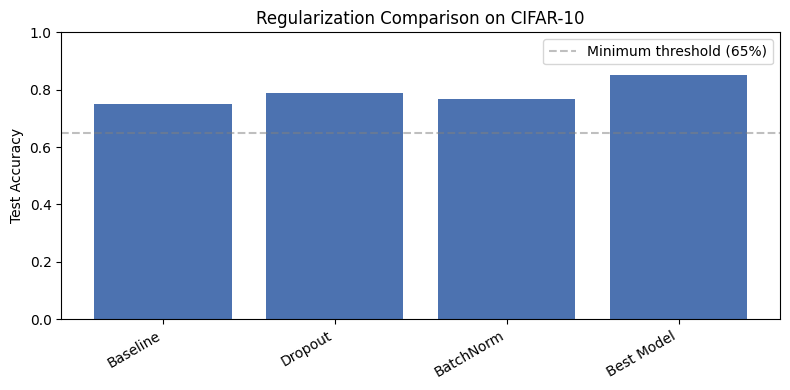

           AUTO-GRADE REPORT
  Baseline            : 75.0%  (>= 65%)  [PASS]
  Dropout             : 78.8%  (>= 65%)  [PASS]
  BatchNorm           : 76.6%  (>= 70%)  [PASS]
  Best Model          : 85.2%  (>= 70%)  [PASS]
---------------------------------------------
  Best Model Accuracy : 85.2%
  Grade               : A+


In [23]:
# Final evaluation on the TEST set (only done here, after all tuning is complete)
print('Final Test Set Evaluation:')
print('=' * 40)
results = {}
for name, model in [('Baseline', baseline), ('Dropout', dropout_model),
                     ('BatchNorm', bn_model), ('Best Model', best_model)]:
    _, acc = evaluate(model, testloader)
    results[name] = acc
    print(f'  {name:15s}: {acc:.4f}')
print('=' * 40)

# --- Bar Chart ---
plt.figure(figsize=(8, 4))
colors = ['#4C72B0' if v >= 0.65 else '#C44E52' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Test Accuracy')
plt.title('Regularization Comparison on CIFAR-10')
plt.ylim(0, 1)
plt.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Minimum threshold (65%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Auto-Grading ---
def compute_grade(best_acc):
    if best_acc >= 0.85: return 'A+'
    elif best_acc >= 0.82: return 'A'
    elif best_acc >= 0.79: return 'B+'
    elif best_acc >= 0.76: return 'B'
    elif best_acc >= 0.70: return 'C'
    else: return 'F'

thresholds = {
    'Baseline': 0.65,
    'Dropout': 0.65,
    'BatchNorm': 0.70,
    'Best Model': 0.70,
}

print('=' * 45)
print('           AUTO-GRADE REPORT')
print('=' * 45)
all_pass = True
for task, threshold in thresholds.items():
    acc = results[task]
    passed = acc >= threshold
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  {task:20s}: {acc:.1%}  (>= {threshold:.0%})  [{status}]')

best = results['Best Model']
grade = compute_grade(best)
print('-' * 45)
print(f'  Best Model Accuracy : {best:.1%}')
print(f'  Grade               : {grade}')
if not all_pass:
    print('  WARNING: Some tasks below minimum threshold!')
print('=' * 45)

### 6-2. Training Curves

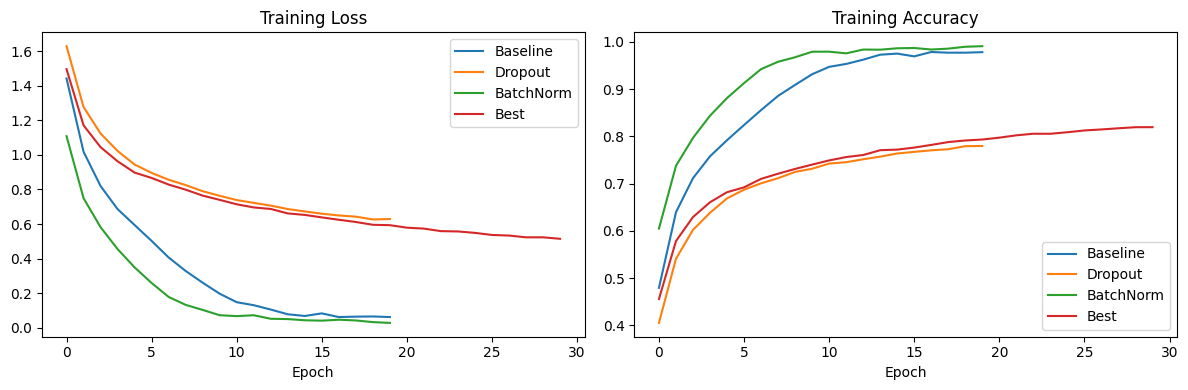

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('Baseline', hist_baseline), ('Dropout', hist_dropout),
                    ('BatchNorm', hist_bn), ('Best', hist_best)]:
    ax1.plot(hist['loss'], label=name)
    ax2.plot(hist['acc'], label=name)

ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

### 6-3. Questions (Answer in text cells below)

1. Which regularization technique (Dropout vs BatchNorm) gave the bigger improvement over the baseline? Why do you think so?
2. Compare the training curves (loss & accuracy) of the baseline vs. your best model. What differences do you observe regarding overfitting?
3. Based on your Grad-CAM visualizations from Task 5, which model (Baseline vs BatchNorm) focuses on more task-relevant image regions? How might this relate to their accuracy difference?

1. Dropout과 BatchNorm 중 어떤 기법이 Baseline 대비 더 큰 향상을 보였는가?
Dropout이 더 큰 향상을 보였습니다 (75.0% → 78.8%, +3.8%p). BatchNorm은 75.0% → 76.6%로 +1.6%p 향상에 그쳤습니다. Training curve를 보면 BatchNorm은 학습 초반부터 training accuracy가 100% 가까이 올라가 심각한 overfitting이 발생했습니다. 반면 Dropout은 학습 중 뉴런을 랜덤으로 꺼버려 overfitting을 효과적으로 억제했습니다. 추가로 Dropout rate 실험에서 0.5로 설정했을 때는 val accuracy가 73.8%에 그쳤지만, 0.25로 낮추었을 때 78.8%로 크게 향상되었습니다. 이는 정규화가 너무 강하면 오히려 모델이 충분히 학습하지 못한다는 것을 보여줍니다.
2. Baseline과 Best Model의 Training curve를 비교하면 overfitting 측면에서 어떤 차이가 있는가?
Baseline과 BatchNorm 모델은 training accuracy가 100% 가까이 올라가는 반면 test accuracy는 75~76%에 머물러 큰 generalization gap이 발생했습니다. 반면 Best Model은 training accuracy가 82~83% 수준으로 억제되었고 test accuracy도 85.2%로 오히려 더 높게 나왔습니다. 이는 BatchNorm + Dropout + Data Augmentation + Weight Decay의 조합이 overfitting을 효과적으로 방지하고 일반화 성능을 크게 향상시켰음을 보여줍니다.

3. Task 5의 Grad-CAM 시각화를 바탕으로, Baseline과 BatchNorm 중 어떤 모델이 더 task와 관련된 영역에 집중하는가?
전반적으로 BatchNorm 모델이 더 task와 관련된 영역에 집중하는 경향을 보였습니다. 고양이 이미지에서 Baseline은 거의 집중하는 영역이 없었던 반면 BatchNorm은 고양이 얼굴과 몸통에 명확히 집중했습니다. 이는 BatchNorm이 각 레이어의 입력 분포를 정규화하여 더 안정적이고 의미 있는 특징을 학습하도록 도와주기 때문으로 보입니다. 다만 사슴 이미지처럼 반대의 경우도 있었기 때문에 BatchNorm이 항상 더 나은 attention을 보장하지는 않으며, 이것이 test accuracy에서도 큰 차이가 나지 않은 이유 중 하나로 볼 수 있습니다.